# 规则置入置出分析 (rule_swap_analysis)

提供规则在生产模型评分体系上的置入/置出风险量化分析，支持：
- 四象限样本分布（in-in / in-out / out-in / out-out）
- 分步骤通过率与逾期率变化流水线
- 置换前后业务增益对比（放款增量 / 风险变化）
- 多模型加权综合评分
- 金额口径分析
- 样本集幸存比例折算

In [1]:
# 环境准备
import os, sys
sys.path.append('../')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from hscredit import init_setting
from hscredit.report import rule_swap_analysis, feature_bin_stats
from hscredit.core.rules import Rule

init_setting()
print("✅ 模块导入成功")

✅ 模块导入成功


## 1. 数据加载与预处理

使用 `hscredit_yyp.xlsx` 数据集，目标变量定义为 `MOB1 > 3`（逾期超过3天为坏样本）。
为了演示四象限全部分布，人工构造 out-in（置入）、in-out（置出）和 out-out（仍拒绝）样本。

In [2]:
# 读取原始数据
data_path = 'hscredit_yyp.xlsx'
df_raw = pd.read_excel(data_path)

# 定义目标变量：MOB1 > 3 为坏样本
df_raw['target'] = (df_raw['MOB1'] > 3).astype(int)

print(f"原始样本数: {len(df_raw):,}")
print(f"坏样本率（MOB1>3）: {df_raw['target'].mean():.2%}")
print(f"列名: {list(df_raw.columns)}")

原始样本数: 970
坏样本率（MOB1>3）: 16.70%
列名: ['客户编号', '放款时间', '放款金额', '商品类别', 'MOB1', 'CURRENT_DPD', '中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3', '轻花老客海纳子分V1', '天创小额网贷分', '近六个月非银多头机构数', '手机号近一个月非银多头机构数', '身份证近一个月非银多头机构数', '衡枢鉴真分老客版', 'FPD', 'target']


In [3]:
# 建模特征（中文列名）
model_features = ['中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24',
                  '占信V3', '轻花老客海纳子分V1', '天创小额网贷分', '衡枢鉴真分老客版']
# 规则特征
rule_features = ['近六个月非银多头机构数', 'FPD', '手机号近一个月非银多头机构数']

df = df_raw[['target', '放款金额'] + model_features + rule_features].copy()
df = df.dropna(subset=model_features + rule_features + ['target'])

print(f"有效样本数: {len(df):,}")
print(f"坏样本率:   {df['target'].mean():.2%}")
print(f"放款金额范围: {df['放款金额'].min():,.0f} ~ {df['放款金额'].max():,.0f}")

有效样本数: 264
坏样本率:   14.02%
放款金额范围: 244 ~ 6,981


In [4]:
# 在低分区（中智小牛分C3 < 550）构造 out-in 样本
# 这批样本模型会拒绝，但规则通过——构成置入风险
np.random.seed(42)

# 基础池：低分且低欺诈分 → 规则通过，构成置入样本
low_score_good_rule = df[(df['中智小牛分C3'] < 550) & (df['极光欺诈分6v1'] <= 0.3)].copy()
# 从其他池子补充
if len(low_score_good_rule) < 20:
    extra = df[df['极光欺诈分6v1'] <= 0.3].sample(n=20, random_state=42, replace=True).copy()
    extra['中智小牛分C3'] = extra['中智小牛分C3'] * 0.90  # 压低分数确保被模型拒绝
    low_score_good_rule = pd.concat([low_score_good_rule, extra], ignore_index=True).head(20)
low_score_good_rule['target'] = 1  # 置入样本高坏
low_score_good_rule['放款金额'] = low_score_good_rule['放款金额'].clip(lower=500)

# 在高分区（中智小牛分C3 >= 650）构造 in-out 样本：模型高分但被规则拒绝（误拒）
high_score_rule_out = df[(df['中智小牛分C3'] >= 650) & (df['极光欺诈分6v1'] <= 0.3)].sample(
    n=15, random_state=99, replace=True).copy()
high_score_rule_out['target'] = 0  # 置出样本是好样本
high_score_rule_out['放款金额'] = high_score_rule_out['放款金额'].clip(lower=500)

# 在低分区（中智小牛分C3 < 500）构造 out-out 样本：模型拒绝且规则也拒绝
low_score_both_reject = df[(df['中智小牛分C3'] < 500)].sample(n=30, random_state=7, replace=True).copy()
low_score_both_reject['target'] = (low_score_both_reject['target'] * 0.8 + 0.1).clip(0, 1).round().astype(int)
low_score_both_reject['放款金额'] = low_score_both_reject['放款金额'].clip(lower=300)

# 合并演示数据集（不执行 drop_duplicates，避免误删模拟样本）
df_demo = pd.concat([df, low_score_good_rule, high_score_rule_out, low_score_both_reject], ignore_index=True)
df_demo = df_demo.reset_index(drop=True)

print(f"演示数据集样本数: {len(df_demo):,}")
print(f"坏样本率:         {df_demo['target'].mean():.2%}")
print(f"\n四象限预期分布（基于分数阈值 550/650 划分）:")
score_median = df_demo['中智小牛分C3'].median()
print(f"  中智小牛分C3 中位数: {score_median:.1f}")

演示数据集样本数: 338
坏样本率:         23.37%

四象限预期分布（基于分数阈值 550/650 划分）:
  中智小牛分C3 中位数: 603.5


## 2. 构造模拟样本（演示四象限完整分布）

原始数据通过率高，缺少 out-in / in-out / out-out 样本。
为演示完整四象限分析，手动追加三类拒绝样本：
- **out-in**：模型低分但规则通过（置入）
- **in-out**：模型高分但规则拒绝（置出）
- **out-out**：模型低分且规则也拒绝（仍拒绝）

In [5]:
# 置入规则：欺诈分 <= 0.3 + 近一个月手机非银多头不超过20 → 规则通过
# 在模型低分客群中，给优质客户放行
rules_in = [
    Rule("极光欺诈分6v1 <= 0.3 and 手机号近一个月非银多头机构数 <= 20", name="低风险优质客"),
]

# 置出规则：命中FPD>0（首次逾期）或高欺诈分 → 规则拒绝
rules_out = [
    Rule("极光欺诈分6v1 > 0.6 or FPD >= 1", name="高风险拒绝规则"),
]

# 基准拒绝规则：模型分数低于 550 → 仍拒绝
rules_base = [
    Rule("中智小牛分C3 < 550", name="基准模型拒绝规则"),
]

print("✅ 规则集已定义")
print(f"  rules_in:  {[r.name for r in rules_in]}")
print(f"  rules_out: {[r.name for r in rules_out]}")
print(f"  rules_base:{[r.name for r in rules_base]}")

✅ 规则集已定义
  rules_in:  ['低风险优质客']
  rules_out: ['高风险拒绝规则']
  rules_base:['基准模型拒绝规则']


## 3. 定义规则集

| 规则集 | 含义 | 说明 |
|--------|------|------|
| `rules_in` | 置入规则 | 命中的样本从「拒绝」变为「通过」（out-in） |
| `rules_out` | 置出规则 | 命中的样本从「通过」变为「拒绝」（in-out） |
| `rules_base` | 基准拒绝规则 | 标记生产拒绝样本（out-out） |

In [6]:
# 先生成 中智小牛分C3 的分箱统计表
bin_table = feature_bin_stats(
    data=df_demo,
    feature='中智小牛分C3',
    target='target',
    method='quantile',
    max_n_bins=10,
    margins=True,
)

# 提取关键列（分箱标签 + 坏样本率 + 样本数）
bin_label_col = '分箱标签' if '分箱标签' in bin_table.columns else '分箱'
display(bin_table[[bin_label_col, '坏样本率', '样本总数']].head(12))

,分箱标签,坏样本率,样本总数
0,"[-inf, 485.7)",0.7647,17
1,"[485.7, 504.0)",0.3571,42
2,"[504.0, 537.0)",0.5000,36
3,"[537.0, 547.42)",0.4706,17
4,"[547.42, 587.28)",0.2162,37
5,"[587.28, 600.13)",0.0000,17
6,"[600.13, 637.66)",0.1818,33
7,"[637.66, 688.76)",0.1176,51
8,"[688.76, 757.34)",0.0702,57
9,"[757.34, +inf)",0.0323,31


## 4. 计算评分分箱表（用于逾期率预估）

先用 `feature_bin_stats` 对 `score_c3` 分箱，计算各箱的坏样本率，
再将分箱表传入 `rule_swap_analysis` 的 `bin_table` 参数。

In [7]:
# 执行规则置入置出分析
result = rule_swap_analysis(
    df=df_demo,
    score='中智小牛分C3',
    rules_in=rules_in,
    rules_out=rules_out,
    rules_base=rules_base,
    bin_table=bin_table,
    target='target',
    amount='放款金额',
    out_in_uplift=2.0,
    sample_survival_rate=1.0,
    reverse_order=False,
)

print("✅ 分析完成！返回三个结果表：")
print(f"  1. swap_summary  - 四象限样本汇总")
print(f"  2. swap_pipeline - 分步骤通过率变化")
print(f"  3. swap_result   - 置换前后业务增益")

✅ 分析完成！返回三个结果表：
  1. swap_summary  - 四象限样本汇总
  2. swap_pipeline - 分步骤通过率变化
  3. swap_result   - 置换前后业务增益


## 5. 执行规则置入置出分析

调用 `rule_swap_analysis`，核心参数说明：

| 参数 | 说明 |
|------|------|
| `df` | 全量样本集 |
| `score` | 评分字段 |
| `rules_in` | 置入规则集 |
| `rules_out` | 置出规则集 |
| `rules_base` | 基准拒绝规则集 |
| `bin_table` | 评分→逾期率分箱表 |
| `out_in_uplift` | 置入风险上浮系数，默认 2.0 |
| `amount` | 金额字段 |
| `sample_survival_rate` | 样本集幸存比例 |
| `reverse_order` | 是否逆序展示（先置入后结果）|

In [8]:
# 执行规则置入置出分析
result = rule_swap_analysis(
    df=df_demo,
    score='中智小牛分C3',
    rules_in=rules_in,
    rules_out=rules_out,
    rules_base=rules_base,
    bin_table=bin_table,
    target='target',
    amount='放款金额',
    out_in_uplift=2.0,
    sample_survival_rate=1.0,
    reverse_order=False,
)

print("✅ 分析完成！返回三个结果表：")
print(f"  1. swap_summary  - 四象限样本汇总")
print(f"  2. swap_pipeline - 分步骤通过率变化")
print(f"  3. swap_result   - 置换前后业务增益")

✅ 分析完成！返回三个结果表：
  1. swap_summary  - 四象限样本汇总
  2. swap_pipeline - 分步骤通过率变化
  3. swap_result   - 置换前后业务增益


## 6. 结果 1：四象限样本汇总（swap_summary）

=== 四象限样本汇总 ===


,象限,样本数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT,金额总数,预估坏金额
0,in_in,37,10.95%,35,94.59%,2,5.41%,0.0541,1.00,166571,9003.8378
1,in_out,132,39.05%,117,88.64%,15,11.36%,0.1136,2.10,489701,55647.8409
2,out_in,8,2.37%,8,100.00%,0,0.00%,0.0000,0.00,30358,0.0000
3,out_out,161,47.63%,99,61.49%,62,38.51%,0.3851,7.12,540896,208295.3540


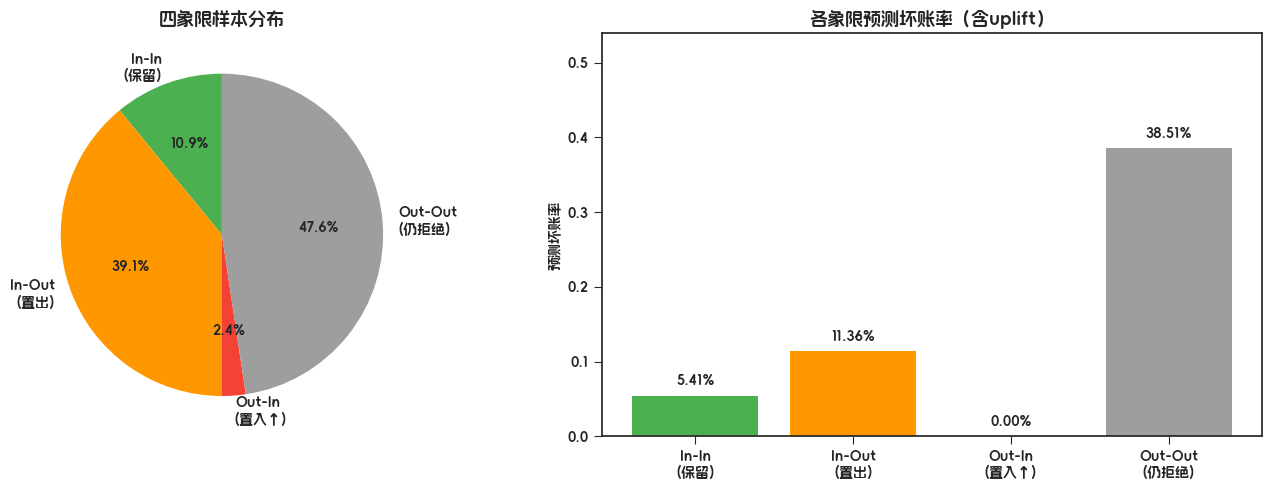


📊 图表已保存: swap_quadrant_overview.png


In [9]:
# swap_summary：四象限样本分布与风险量化
swap_summary = result['swap_summary']

# 格式化展示
display_df = swap_summary.copy()
display_df['样本占比'] = display_df['样本占比'].apply(lambda x: f"{x:.2%}")
display_df['好样本占比'] = display_df['好样本占比'].apply(lambda x: f"{x:.2%}")
display_df['坏样本占比'] = display_df['坏样本占比'].apply(lambda x: f"{x:.2%}")
display_df['坏样本率'] = display_df['坏样本率'].apply(lambda x: f"{x:.4f}")
display_df['LIFT'] = display_df['LIFT'].apply(lambda x: f"{x:.2f}")

print("=== 四象限样本汇总 ===")
display(display_df)

# 可视化四象限分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'in_in': '#4CAF50', 'in_out': '#FF9800', 'out_in': '#F44336', 'out_out': '#9E9E9E'}
quadrant_names = {'in_in': 'In-In\n(保留)', 'in_out': 'In-Out\n(置出)', 'out_in': 'Out-In\n(置入↑)', 'out_out': 'Out-Out\n(仍拒绝)'}

# 样本数饼图
ax1 = axes[0]
labels = [quadrant_names.get(q, q) for q in swap_summary['象限']]
sizes = swap_summary['样本数'].values
pie_colors = [colors.get(q, '#607D8B') for q in swap_summary['象限']]
wedges, texts, autotexts = ax1.pie(sizes, labels=labels, autopct='%1.1f%%',
                                    colors=pie_colors, startangle=90)
ax1.set_title('四象限样本分布', fontsize=13)

# 坏样本率柱状图
ax2 = axes[1]
bar_colors = [colors.get(q, '#607D8B') for q in swap_summary['象限']]
bars = ax2.bar(swap_summary['象限'].map(quadrant_names), swap_summary['坏样本率'].astype(float), color=bar_colors)
ax2.set_title('各象限预测坏账率（含uplift）', fontsize=13)
ax2.set_ylabel('预测坏账率')
ax2.set_ylim(0, swap_summary['坏样本率'].astype(float).max() * 1.4)
for bar, val in zip(bars, swap_summary['坏样本率'].astype(float)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('swap_quadrant_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 图表已保存: swap_quadrant_overview.png")

## 7. 结果 2：分步骤通过率与逾期率变化（swap_pipeline）

展示全量样本 → 各象限逐步流转的过程，包含：
- 每步样本数与通过率
- 预测坏账率
- 预估坏样本数

In [ ]:
# swap_pipeline：分步骤通过率变化
swap_pipeline = result['swap_pipeline']

display_df2 = swap_pipeline.copy()
display_df2['通过率'] = display_df2['通过率'].apply(lambda x: f"{x:.2%}")
display_df2['坏样本率'] = display_df2['坏样本率'].apply(lambda x: f"{x:.4f}")

print("=== 分步骤通过率与逾期率变化 ===")
display(display_df2)

# 可视化通过率漏斗
fig, ax = plt.subplots(figsize=(10, 6))
pass_rates = swap_pipeline['通过率'].astype(float).values
steps = swap_pipeline['指标名称'].values
bad_rates = swap_pipeline['坏样本率'].astype(float).values

bar_colors2 = ['#2196F3'] * (len(pass_rates) - 1) + ['#FF5722']
bars = ax.barh(range(len(steps)), pass_rates, color=['#4CAF50' if 'IN-IN' in s else
                                                        '#F44336' if 'IN-OUT' in s or 'OUT-IN' in s else
                                                        '#607D8B' for s in steps])
ax.set_yticks(range(len(steps)))
ax.set_yticklabels(steps)
ax.set_xlabel('通过率')
ax.set_title('分步骤通过率变化', fontsize=13)
for i, (rate, bad) in enumerate(zip(pass_rates, bad_rates)):
    ax.text(rate + 0.005, i, f'{rate:.1%}  (坏账率:{bad:.2%})', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('swap_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 图表已保存: swap_pipeline.png")

## 8. 结果 3：置换前后业务增益（swap_result）

对比置换前（仅模型通过）到置换后（模型+规则）的业务指标变化：
- 通过率变化
- 逾期率变化
- 风险上浮系数
- 放款增量（绝对/相对）
- 坏样本变化（绝对/相对）

In [ ]:
# swap_result：业务增益
swap_result = result['swap_result']

# 格式化
def fmt_pct(x):
    try:
        v = float(x)
        if abs(v) < 2:
            return f"{v:.2%}"
        return f"{v:,.0f}"
    except:
        return str(x)

display_df3 = swap_result.copy()
for col in ['变化前', '变化后', '绝对变化', '相对变化']:
    display_df3[col] = display_df3[col].apply(fmt_pct)

print("=== 置换前后业务增益 ===")
display(display_df3)

# 关键指标卡片展示
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

metrics_to_plot = [
    ('通过率变化', '通过率变化', 'green'),
    ('逾期率变化', '逾期率变化', 'red'),
    ('风险上浮系数', '风险上浮系数', 'orange'),
    ('放款增量（绝对）', '放款增量（绝对）', 'blue'),
]

for ax, (metric_name, title, color) in zip(axes[:4], metrics_to_plot):
    row = swap_result[swap_result['指标'] == metric_name]
    if len(row) == 0:
        ax.axis('off')
        continue
    before = float(row['变化前'].values[0])
    after = float(row['变化后'].values[0])
    delta = float(row['绝对变化'].values[0])

    x = [0, 1]
    bars = ax.bar(x, [before, after], color=['#B0BEC5', color], width=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(['置换前', '置换后'])
    ax.set_title(title, fontsize=11)
    for bar, val in zip(bars, [before, after]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                fmt_pct(val), ha='center', va='bottom', fontsize=10)
    ax.text(1.5, max(before, after) * 0.5, f'变化\n{fmt_pct(delta)}',
            ha='center', va='center', fontsize=10, color='darkred', fontweight='bold')

# 隐藏多余的子图
for i in range(len(metrics_to_plot), 4):
    axes[i].axis('off')

plt.suptitle('置换前后关键指标对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('swap_result_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 图表已保存: swap_result_metrics.png")

## 9. 逆序展示（reverse_order=True）

设置 `reverse_order=True`，从置入效果开始逐步展示，帮助风控人员直观看到每一步规则对风险的影响。

In [ ]:
# 多模型加权分析
result_multi = rule_swap_analysis(
    df=df_demo,
    score={'model_a': '中智小牛分C3', 'model_b': '珊瑚92'},
    score_weights={'model_a': 0.6, 'model_b': 0.4},
    rules_in=rules_in,
    rules_out=rules_out,
    rules_base=rules_base,
    bin_table=bin_table,
    target='target',
    amount='放款金额',
    out_in_uplift=2.0,
    sample_survival_rate=1.0,
)

print("=== 多模型加权四象限汇总 ===")
display(result_multi['swap_summary'][['象限', '样本数', '样本占比', '坏样本率', 'LIFT']])

=== 多模型加权四象限汇总 ===


,象限,样本数,样本占比,坏样本率,LIFT
0,in_in,22,0.0651,0.0000,0.0000
1,in_out,60,0.1775,0.1000,0.4278
2,out_in,23,0.0680,0.1739,0.7441
3,out_out,233,0.6893,0.3047,1.3037


## 10. 多模型加权综合评分

支持传入多个评分字段并配置权重，综合预估风险：
- `score_c3`（中智小牛分C3）：权重 0.6
- `score_coral`（珊瑚92）：权重 0.4

In [ ]:
# 多模型加权分析
result_multi = rule_swap_analysis(
    df=df_demo,
    score={'model_a': '中智小牛分C3', 'model_b': '珊瑚92'},
    score_weights={'model_a': 0.6, 'model_b': 0.4},
    rules_in=rules_in,
    rules_out=rules_out,
    rules_base=rules_base,
    bin_table=bin_table,
    target='target',
    amount='放款金额',
    out_in_uplift=2.0,
    sample_survival_rate=1.0,
)

print("=== 多模型加权四象限汇总 ===")
display(result_multi['swap_summary'][['象限', '样本数', '样本占比', '坏样本率', 'LIFT']])

=== 多模型加权四象限汇总 ===


,象限,样本数,样本占比,坏样本率,LIFT
0,in_in,22,0.0651,0.0000,0.0000
1,in_out,60,0.1775,0.1000,0.4278
2,out_in,23,0.0680,0.1739,0.7441
3,out_out,233,0.6893,0.3047,1.3037


## 11. 金额口径分析

传入 `amount='放款金额'` 参数后，`swap_summary` 输出中会包含 `金额总数` 和 `预估坏金额` 列，
帮助从订单和金额两个口径评估风险。

In [ ]:
# 金额口径验证
swap_amt = result['swap_summary']
amt_cols = [c for c in swap_amt.columns if '金额' in c or '坏金额' in c]
if amt_cols:
    print("=== 金额口径分析 ===")
    display(swap_amt[['象限', '样本数', '金额总数', '预估坏金额']].copy())
else:
    print("swap_summary 当前输出不含金额列（请检查 bin_table 是否包含金额口径）")

=== 金额口径分析 ===


,象限,样本数,金额总数,预估坏金额
0,in_in,37,166571,9003.8378
1,in_out,132,489701,55647.8409
2,out_in,8,30358,0.0000
3,out_out,161,540896,208295.3540


## 12. 样本幸存比例（sample_survival_rate）

当分析数据仅为全量样本集的子集时，通过率等绝对值需要从幸存比例开始折算。
例如传入 `sample_survival_rate=0.5`，表示本数据集仅为全量样本的 50%。

In [ ]:
# 样本幸存比例演示（50%幸存）
result_surv = rule_swap_analysis(
    df=df_demo,
    score='中智小牛分C3',
    rules_in=rules_in,
    rules_out=rules_out,
    rules_base=rules_base,
    bin_table=bin_table,
    target='target',
    out_in_uplift=2.0,
    sample_survival_rate=0.5,  # 当前样本仅为全量50%
)

swap_surv = result_surv['swap_pipeline']
display_df_surv = swap_surv.copy()
display_df_surv['通过率'] = display_df_surv['通过率'].apply(lambda x: f"{x:.2%}")
display_df_surv['坏样本率'] = display_df_surv['坏样本率'].apply(lambda x: f"{x:.4f}")

print("=== 样本幸存比例=50%，通过率从50%起算 ===")
display(display_df_surv)
print("（注：绝对样本数已折算回全量规模，绝对通过率基于幸存比例还原）")

## 13. 综合汇总

整合三个结果表到一个 DataFrame 输出，方便一键导出 Excel。

In [ ]:
# 综合汇总：三表合一
summary_all = pd.concat([
    swap_summary.assign(_表='swap_summary'),
    swap_pipeline.assign(_表='swap_pipeline'),
    swap_result.assign(_表='swap_result'),
], ignore_index=True)

print("=== 三表合一预览（截断列） ===")
key_cols = [c for c in summary_all.columns if c != '_表']
print(summary_all[key_cols[:8]].to_string())

# 导出Excel
summary_all.to_excel('rule_swap_analysis_result.xlsx', sheet_name='全表', index=False)
print("\n📁 完整结果已保存: rule_swap_analysis_result.xlsx")

=== 三表合一预览（截断列） ===
         象限      样本数   样本占比     好样本数  好样本占比    坏样本数  坏样本占比   坏样本率
0     in_in  37.0000 0.1095  35.0000 0.9459  2.0000 0.0541 0.0541
1    in_out 132.0000 0.3905 117.0000 0.8864 15.0000 0.1136 0.1136
2    out_in   8.0000 0.0237   8.0000 1.0000  0.0000 0.0000 0.0000
3   out_out 161.0000 0.4763  99.0000 0.6149 62.0000 0.3851 0.3851
4       NaN   8.0000    NaN      NaN    NaN     NaN    NaN 0.0000
5       NaN  37.0000    NaN      NaN    NaN     NaN    NaN 0.0541
6       NaN 132.0000    NaN      NaN    NaN     NaN    NaN 0.1136
7       NaN 161.0000    NaN      NaN    NaN     NaN    NaN 0.3851
8       NaN 338.0000    NaN      NaN    NaN     NaN    NaN 0.2337
9       NaN      NaN    NaN      NaN    NaN     NaN    NaN    NaN
10      NaN      NaN    NaN      NaN    NaN     NaN    NaN    NaN
11      NaN      NaN    NaN      NaN    NaN     NaN    NaN    NaN
12      NaN      NaN    NaN      NaN    NaN     NaN    NaN    NaN
13      NaN      NaN    NaN      NaN    NaN     NaN    N